# Euclidean Distance Between Vectors

This notebook demonstrates how to compute the Euclidean distance between two vectors using PyTorch.

## What is Euclidean Distance?

Euclidean distance is the straight-line distance between two points in Euclidean space. It is the most common distance metric used in mathematics, physics, and machine learning. The Euclidean distance between two vectors represents how far apart they are in multidimensional space.

### Mathematical Definition

For two vectors $\mathbf{x}, \mathbf{y} \in \mathbb{R}^d$ in $d$-dimensional space:

$$\mathbf{x} = \begin{bmatrix} x_1 \\ x_2 \\ \vdots \\ x_d \end{bmatrix}, \quad \mathbf{y} = \begin{bmatrix} y_1 \\ y_2 \\ \vdots \\ y_d \end{bmatrix}$$

The **Euclidean Distance** is defined as:

$$d(\mathbf{x}, \mathbf{y}) = \|\mathbf{x} - \mathbf{y}\|_2 = \sqrt{\sum_{i=1}^{d} (x_i - y_i)^2} = \sqrt{(x_1 - y_1)^2 + (x_2 - y_2)^2 + \cdots + (x_d - y_d)^2}$$

**Key Properties**:

- Euclidean distance is always **non-negative**: $d(\mathbf{x}, \mathbf{y}) \geq 0$

- Distance from a vector to itself is **zero**: $d(\mathbf{x}, \mathbf{x}) = 0$

- Euclidean distance is **symmetric**: $d(\mathbf{x}, \mathbf{y}) = d(\mathbf{y}, \mathbf{x})$

- Distance satisfies the **triangle inequality**: $d(\mathbf{x}, \mathbf{z}) \leq d(\mathbf{x}, \mathbf{y}) + d(\mathbf{y}, \mathbf{z})$

- Euclidean distance is equivalent to the **L2 norm** of the difference vector: $d(\mathbf{x}, \mathbf{y}) = \|\mathbf{x} - \mathbf{y}\|_2$

- **Geometric interpretation**: In 2D, it is the straight-line distance between two points; in higher dimensions, it extends this concept

In [23]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Create two vectors with a larger angle between them for better visualization
x = torch.tensor([3.0, 0.0])
y = torch.tensor([1.0, 3.0])

print(f"Vector x = {x}")
print(f"Vector y = {y}")

Vector x = tensor([3., 0.])
Vector y = tensor([1., 3.])


In [24]:
# Calculate the difference vector
diff = x - y
print(f"Difference vector: x - y = {diff}")
print(f"Components: (x₁ - y₁) = {diff[0]}, (x₂ - y₂) = {diff[1]}")

Difference vector: x - y = tensor([ 2., -3.])
Components: (x₁ - y₁) = 2.0, (x₂ - y₂) = -3.0


In [25]:
# Calculate Euclidean distance manually
distance_manual = torch.sqrt(torch.sum(diff ** 2))
print(f"Euclidean distance (manual): d(x, y) = sqrt({diff[0]**2:.1f} + {diff[1]**2:.1f}) = sqrt({torch.sum(diff ** 2):.1f}) = {distance_manual:.4f}")

Euclidean distance (manual): d(x, y) = sqrt(4.0 + 9.0) = sqrt(13.0) = 3.6056


In [26]:
# Calculate Euclidean distance using torch.norm()
distance_torch = torch.norm(x - y)
print(f"Euclidean distance (torch.norm): d(x, y) = {distance_torch:.4f}")
print(f"Verification: Both methods give same result? {torch.allclose(distance_manual, distance_torch)}")

Euclidean distance (torch.norm): d(x, y) = 3.6056
Verification: Both methods give same result? True


## Visualization of Euclidean Distance

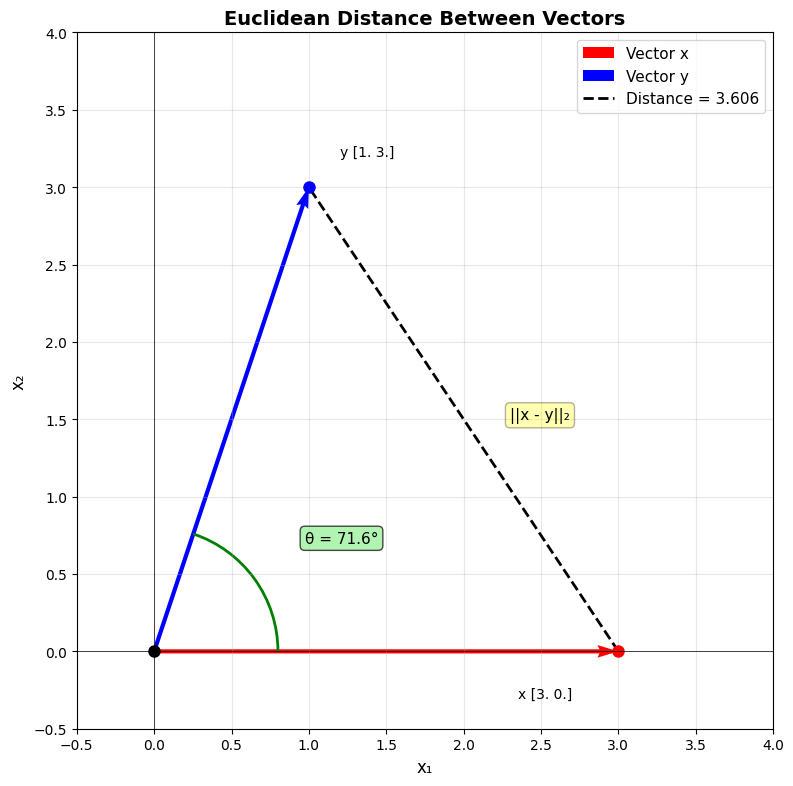

In [27]:
# Create a visualization showing two vectors and their Euclidean distance
fig, ax = plt.subplots(figsize=(8, 8))

# Origin
origin = np.array([0, 0])

# Convert tensors to numpy for plotting
x_np = x.numpy()
y_np = y.numpy()

# Plot vectors from origin
ax.quiver(origin[0], origin[1], x_np[0], x_np[1], angles='xy', scale_units='xy', scale=1, color='red', width=0.006, label='Vector x')
ax.quiver(origin[0], origin[1], y_np[0], y_np[1], angles='xy', scale_units='xy', scale=1, color='blue', width=0.006, label='Vector y')

# Plot the distance as a dashed line between endpoints
ax.plot([x_np[0], y_np[0]], [x_np[1], y_np[1]], 'k--', linewidth=2, label=f'Distance = {distance_torch:.3f}')

# Plot points at endpoints
ax.plot(*x_np, 'ro', markersize=8)
ax.plot(*y_np, 'bo', markersize=8)
ax.plot(*origin, 'ko', markersize=8)

# Calculate angle between vectors
dot_product = torch.dot(x, y)
magnitude_x = torch.norm(x)
magnitude_y = torch.norm(y)
cos_theta = dot_product / (magnitude_x * magnitude_y)
# Clamp to avoid numerical errors with arccos
cos_theta = torch.clamp(cos_theta, -1, 1)
angle_rad = torch.acos(cos_theta)
angle_deg = torch.rad2deg(angle_rad)

# Draw angle arc between the two vectors
from matplotlib.patches import Arc
radius = 0.8
arc_angle = Arc((origin[0], origin[1]), 2*radius, 2*radius, 
                angle=0, theta1=np.degrees(np.arctan2(x_np[1], x_np[0])), 
                theta2=np.degrees(np.arctan2(y_np[1], y_np[0])), 
                color='green', linewidth=2)
ax.add_patch(arc_angle)

# Add angle label
mid_angle_rad = (np.arctan2(x_np[1], x_np[0]) + np.arctan2(y_np[1], y_np[0])) / 2
label_radius = 1.2
ax.text(label_radius * np.cos(mid_angle_rad), label_radius * np.sin(mid_angle_rad), 
        f'θ = {angle_deg.item():.1f}°', fontsize=11, 
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

# Add labels
ax.text(x_np[0] - 0.3, x_np[1] - 0.3, f'x {x_np}', fontsize=10, ha='right')
ax.text(y_np[0] + 0.2, y_np[1] + 0.2, f'y {y_np}', fontsize=10, ha='left')
ax.text((x_np[0] + y_np[0])/2 + 0.3, (x_np[1] + y_np[1])/2, f'||x - y||₂', fontsize=11, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

# Set axis properties
ax.set_xlim(-0.5, 4)
ax.set_ylim(-0.5, 4)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)
ax.set_xlabel('x₁', fontsize=12)
ax.set_ylabel('x₂', fontsize=12)
ax.set_title('Euclidean Distance Between Vectors', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

## Euclidean Distance with Different Dimensions

In [28]:
# 1D vectors
v1_1d = torch.tensor([3.0])
v2_1d = torch.tensor([7.0])
dist_1d = torch.norm(v1_1d - v2_1d)
print(f"1D: v1 = {v1_1d}, v2 = {v2_1d}")
print(f"    Distance = {dist_1d:.4f}")
print()

# 2D vectors
v1_2d = torch.tensor([1.0, 2.0])
v2_2d = torch.tensor([4.0, 6.0])
dist_2d = torch.norm(v1_2d - v2_2d)
print(f"2D: v1 = {v1_2d}, v2 = {v2_2d}")
print(f"    Distance = {dist_2d:.4f}")
print()

# 3D vectors
v1_3d = torch.tensor([1.0, 2.0, 3.0])
v2_3d = torch.tensor([4.0, 5.0, 6.0])
dist_3d = torch.norm(v1_3d - v2_3d)
print(f"3D: v1 = {v1_3d}, v2 = {v2_3d}")
print(f"    Distance = {dist_3d:.4f}")
print()

# High-dimensional vectors
v1_hd = torch.tensor([1.0, 2.0, 3.0, 4.0, 5.0])
v2_hd = torch.tensor([2.0, 3.0, 4.0, 5.0, 6.0])
dist_hd = torch.norm(v1_hd - v2_hd)
print(f"5D: v1 = {v1_hd}")
print(f"    v2 = {v2_hd}")
print(f"    Distance = {dist_hd:.4f}")

1D: v1 = tensor([3.]), v2 = tensor([7.])
    Distance = 4.0000

2D: v1 = tensor([1., 2.]), v2 = tensor([4., 6.])
    Distance = 5.0000

3D: v1 = tensor([1., 2., 3.]), v2 = tensor([4., 5., 6.])
    Distance = 5.1962

5D: v1 = tensor([1., 2., 3., 4., 5.])
    v2 = tensor([2., 3., 4., 5., 6.])
    Distance = 2.2361


## Distance Between Multiple Vector Pairs

In [29]:
# Create multiple vector pairs
vectors_x = torch.tensor([
    [1.0, 2.0],
    [3.0, 4.0],
    [5.0, 6.0]
])

vectors_y = torch.tensor([
    [4.0, 6.0],
    [6.0, 8.0],
    [8.0, 10.0]
])

# Calculate distances for all pairs
distances = torch.norm(vectors_x - vectors_y, dim=1)

print("Vector pairs and their Euclidean distances:")
for i in range(len(vectors_x)):
    print(f"Pair {i+1}: {vectors_x[i]} -> {vectors_y[i]}, Distance = {distances[i]:.4f}")

Vector pairs and their Euclidean distances:
Pair 1: tensor([1., 2.]) -> tensor([4., 6.]), Distance = 5.0000
Pair 2: tensor([3., 4.]) -> tensor([6., 8.]), Distance = 5.0000
Pair 3: tensor([5., 6.]) -> tensor([ 8., 10.]), Distance = 5.0000


## Properties of Euclidean Distance

In [30]:
# Property 1: Distance from vector to itself is zero
v = torch.tensor([3.0, 4.0, 5.0])
dist_self = torch.norm(v - v)
print(f"Property 1 - Distance to self:")
print(f"v = {v}")
print(f"d(v, v) = {dist_self:.4f}")
print()

# Property 2: Symmetry - d(x, y) = d(y, x)
x = torch.tensor([1.0, 2.0])
y = torch.tensor([4.0, 6.0])
dist_xy = torch.norm(x - y)
dist_yx = torch.norm(y - x)
print(f"Property 2 - Symmetry:")
print(f"x = {x}, y = {y}")
print(f"d(x, y) = {dist_xy:.4f}")
print(f"d(y, x) = {dist_yx:.4f}")
print(f"Are they equal? {torch.allclose(dist_xy, dist_yx)}")
print()

# Property 3: Triangle inequality - d(x, z) <= d(x, y) + d(y, z)
x = torch.tensor([0.0, 0.0])
y = torch.tensor([3.0, 0.0])
z = torch.tensor([3.0, 4.0])
dist_xz = torch.norm(x - z)
dist_xy = torch.norm(x - y)
dist_yz = torch.norm(y - z)
sum_xy_yz = dist_xy + dist_yz
print(f"Property 3 - Triangle Inequality:")
print(f"x = {x}, y = {y}, z = {z}")
print(f"d(x, z) = {dist_xz:.4f}")
print(f"d(x, y) + d(y, z) = {dist_xy:.4f} + {dist_yz:.4f} = {sum_xy_yz:.4f}")
print(f"d(x, z) <= d(x, y) + d(y, z)? {dist_xz.item() <= sum_xy_yz.item()}")

Property 1 - Distance to self:
v = tensor([3., 4., 5.])
d(v, v) = 0.0000

Property 2 - Symmetry:
x = tensor([1., 2.]), y = tensor([4., 6.])
d(x, y) = 5.0000
d(y, x) = 5.0000
Are they equal? True

Property 3 - Triangle Inequality:
x = tensor([0., 0.]), y = tensor([3., 0.]), z = tensor([3., 4.])
d(x, z) = 5.0000
d(x, y) + d(y, z) = 3.0000 + 4.0000 = 7.0000
d(x, z) <= d(x, y) + d(y, z)? True


## Applications of Euclidean Distance

**Machine Learning:**
- K-Nearest Neighbors (KNN): Find the k nearest data points based on Euclidean distance
- K-Means Clustering: Assign points to clusters based on distance to centroids
- Distance-based anomaly detection

**Computer Vision:**
- Image similarity: Compare feature vectors of images
- Face recognition: Measure distance between face embeddings
- Object tracking: Calculate distance between consecutive frame positions

**Recommendation Systems:**
- User similarity: Find similar users based on preference vectors
- Item similarity: Recommend items based on feature distance

**Physics & Engineering:**
- Calculate distance between points in 3D space
- Measure deviations from target positions
- Trajectory analysis and motion planning